# Information
## General workflow
1. Create a file list of the data files from different source folders needed for modeling
2. Read the rasters and convert them into a dataframe with column names acording to the file names
3. Check outliers for each numerial column and set those to the nearest value within the 1.5 IQR range
4. Impute (basic imputation to get some progress, but not very suitable for spatial data)<br>
4.1 Numerical columns (mean)<br>
4.2 Categorical columns (zeros)<br>
6. Scale the data (numerical columns only)
7. Add the mask based on the base raster and remove the rows with missing values
8. Prepare data for modeling:
   - Split the data into train and test sets
   - Sample data
9. Train and evaluate the model
10. Predict on full dataset (imputed, scaled)

**To be able to create models or do the evaluation, you need to have the data files in the correct folders and run all cells above section 8 (Modeling)**.<p>
## Instructions
The notebook is ready to run.

Runs will be logged as TFEvents, and models saved as .keras. The final result is a **map output** containing the favourabilities for mineral occurences (GeoTIFF).<br>
At the end of the notebook, you'll find a section to evaluate already trained models.<p>
All models contain a date-id in the model name, so you can easily identify different runs.


# Set up

In [1]:
import sys
if sys.version_info < (3, 9):
    from importlib_resources import files
else:
    from importlib.resources import files

import numpy as np
import pandas as pd
import seaborn as sns
import rasterio
import tensorflow as tf

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import gc
import datetime

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from tqdm import tqdm
from collections import Counter

import sys, os, warnings
from pathlib import Path

# Custom modules
from beak.utilities.io import load_model, save_raster, check_path, save_input_file_list
from beak.utilities.eda import clip_outliers
from beak.utilities.preparation import impute_data
from beak.utilities.transformation import _scale_data
from beak.utilities.raster_processing import unify_raster_grids
from beak.models import cobalt_nickel_upper_midwest                   # Includes the model definitions used in this notebook 

BASE_PATH = files("beak.data")
gc.enable()


**User** inputs

In [3]:
# Choose model
MODEL = "FEATURE_FOX"
MODEL_BASE_PATH = "models" / Path("ANN" + "_" + MODEL + "_clipped_nat")
check_path(MODEL_BASE_PATH)
model = cobalt_nickel_upper_midwest.models[MODEL]

PATH_DATA = BASE_PATH / "PROCESSED" / "regional_102003_500_upper_midwest_cobalt_nickel" / "clipped_area" / "unified_ta2_hm6_nat"
PATH_LOG_DATA = BASE_PATH / "PROCESSED" / "regional_102003_500_upper_midwest_cobalt_nickel" / "clipped_area" / "unified_ta2_hm6_nat_scaled_log"
PATH_LABELS = BASE_PATH / "TRAINING_LABELS" / "COBALT_NICKEL_UPPER_MIDWEST" / "EPSG_102003_RES_500_UpperMidwest_CLP_TA2_HM6_NAT_MMS_TA2HM6.tif"
PATH_BASE_RASTER = BASE_PATH / "BASE_RASTERS" / "EPSG_102003_RES_500_UpperMidwest_CLP_TA2_HM6_NAT.tif"
PATH_BASE_RASTER_REG = BASE_PATH / "BASE_RASTERS" / "EPSG_102003_RES_500_UpperMidwest_CLP.tif"

# Special handling for imputing log-transformed data with minimum value
IMPUTE_MIN = []

LABELS_COL = "LABELS"
BASE_RASTER_COL = "BASE_RASTER"

SEED = 42
SCALER_TYPE = "standard"


Other settings

In [3]:
def get_timestamp():
    return datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

def create_model_folder(model_name, model_base_path=MODEL_BASE_PATH):
  model_path = model_base_path / str(model_name + "_" + get_timestamp())
  check_path(model_path)
  return model_path

seed = SEED
scaler_type = SCALER_TYPE

# 0: Functions

## General

**Save** and **load** models

In [4]:
def save_ml_model(model, model_name, path):
  """Saves model to disk"""
  model_path = check_path(path / "model")
  model.save(model_path / str(model_name + ".keras"))
  

def load_ml_model(model_name, path):
  """Loads model from disk"""
  path = Path(path)
  model_path = path / "model" / str(model_name + ".keras")
  return keras.models.load_model(model_path)


**Create** callbacks

In [5]:
def tensorboard_callback(folder):
  log_dir = folder
  
  training_log = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
  print(f"Saving TensorBoard log files to: {log_dir}")
  return training_log


**Shape** to spatial extent/shape

In [6]:
def shape_df_to_spatial_extent(data, labels):
  df_shaped = data.copy()
  df_shaped = pd.concat([df_shaped, pd.DataFrame(labels.reshape(-1, 1), columns=["LABELS"])], axis=1)

  df_shaped.dropna(how="any", inplace=True)
  print(f"Data rows for all values: {df_shaped.shape[0]}, data columns: {df_shaped.shape[1]}")

  num_negatives = df_shaped[df_shaped[LABELS_COL] == 0].shape[0]
  print("\nData rows for Absent values:", num_negatives)

  num_positives = df_shaped[df_shaped[LABELS_COL] == 1].shape[0]
  print("Data rows for Present values:", num_positives)

  return df_shaped


## Subsetting data and sampling

**Oversampling** the initial data with simple oversampling

In [7]:
from imblearn.over_sampling import RandomOverSampler

def oversample_data(X, y, sampling_strategy=0.5, random_state=seed, shrinkage=0.0):
  ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=seed, shrinkage=shrinkage)
  X_ros, y_ros = ros.fit_resample(X, y)
  print(f"Resampled dataset shape {Counter(y_ros)}, positive/negative ratio: {round(Counter(y_ros)[1] / Counter(y_ros)[0], 2)}")
  
  return X_ros.astype(np.float32), y_ros.astype(np.int8)


**Create** subsets

In [8]:
def create_subsets(X, y, num_downsampling, ground_truth=LABELS_COL, seed=seed):
  Xy = pd.concat([X, y], axis=1)
  Xy_subset = Xy.sample(n=num_downsampling, random_state=seed)

  X_subset = Xy_subset.drop(columns=[ground_truth], inplace=False)
  y_subset = Xy_subset[ground_truth]
  print(f"Subset dataset shape {Counter(y_subset)}")

  return X_subset, y_subset


def select_random_samples(X, y, sampling_strategy=0.1, sampling_class="negatives", seed=seed):
  X_positives = X[y == 1] 
  X_negatives = X[y == 0]

  X_samples = X_negatives if sampling_class == "negatives" else X_positives
  X_samples = X_samples.sample(frac=sampling_strategy, random_state=seed, replace=False)

  X_positives = X_samples if sampling_class == "positives" else X_positives
  X_negatives = X_samples if sampling_class == "negatives" else X_negatives
  
  X_samples = pd.concat([X_positives, X_negatives], axis=0)
  y_samples = np.concatenate([np.ones(X_positives.shape[0]), np.zeros(X_negatives.shape[0])])

  print(f"Subset dataset shape {Counter(y_samples)}")
  return X_samples, y_samples


In [9]:
def create_number_of_random_negatives(X, y, multiplier=20, decimals=3):
  y_positives = y[y == 1]
  random_num_negatives = len(y_positives) * multiplier
  ratio = round(random_num_negatives / len(X), decimals)
  return ratio


## Create models

**Building** and **training** ANN models

In [10]:
from tensorflow.keras.metrics import BinaryAccuracy

def train_ann(X, 
              y,
              model,
              validation_data=None, 
              validation_split=0.2,  
              validation_steps=None,
              epochs=100, 
              batch_size=32, 
              optimizer=tf.keras.optimizers.Adam, 
              loss=tf.keras.losses.binary_crossentropy, 
              metrics=[tf.keras.metrics.BinaryAccuracy()], 
              callbacks=[], 
              verbose=0,
              seed=42,
              mixed_precision=False):
  """Train ANN model"""
  # Set mixed precision policy
  if mixed_precision is True:
    tf.keras.mixed_precision.set_global_policy(policy='mixed_float16')
  else:
    tf.keras.mixed_precision.set_global_policy(policy='float32')

  tf.random.set_seed(seed)  

  # Print settings
  print(f"Random seed: {seed}, precision: {tf.keras.mixed_precision.global_policy().name}\n")
  
  if validation_data:
    print(f"Training on {X.shape[0]} samples.\n")
  else:
    print(f"Training on {int(X.shape[0] - X.shape[0] * validation_split)} samples.\n")
    
  model.compile(optimizer=optimizer(learning_rate=0.001), loss=loss, metrics=metrics)
  return model.fit(X, y, validation_data=validation_data, validation_split=validation_split, validation_steps=validation_steps, epochs=epochs, batch_size=batch_size, callbacks=callbacks, verbose=verbose)
    

Simple initial **ANN**

In [11]:
# Simple initial ANN model
def create_simple_ann(num_features, model_name="ANN", hidden_units=1, activation=tf.keras.activations.relu, batch_norm=False, seed=42):
  """Create a new ANN model"""  
  tf.random.set_seed(seed)
  neurons = num_features*2 + 1

  input = tf.keras.Input(shape=(num_features,), name="Input_layer")
  x = layers.Dense(neurons, activation=activation, name="Hidden_layer_1")(input)
  x = layers.BatchNormalization()(x) if batch_norm is True else x
  
  if hidden_units > 1:
    for i in range(1, hidden_units):
      hidden_unit_name = f"Hidden_layer_{i+1}"
      x = layers.Dense(neurons, activation=activation, name=hidden_unit_name)(x)
      x = layers.BatchNormalization()(x) if batch_norm is True else x  
       
  output = layers.Dense(1, activation=tf.keras.activations.sigmoid, dtype=tf.float32, name="Output_layer")(x)
  return tf.keras.Model(inputs=input, outputs=output, name=model_name)


**C1: Complex** ANN with ascending order of neurons to the power of 2

In [12]:
# Create complex ANN models
def create_ann_c1(num_features, model_name="ANN", min_exp=6, hidden_units=1, activation=tf.keras.activations.relu, batch_norm=False, seed=42):
  """Create a new ANN model"""  
  tf.random.set_seed(seed)

  neurons = 2**min_exp
  input = tf.keras.Input(shape=(num_features,), name="Input_layer")
  x = layers.Dense(2**min_exp, activation=activation, name="Hidden_layer_1")(input)
  x = layers.BatchNormalization()(x) if batch_norm is True else x
  
  if hidden_units > 1:
    for i in range(1, hidden_units):
      neurons = 2**(min_exp + i)
      hidden_unit_name = f"Hidden_layer_{i+1}"
      x = layers.Dense(neurons, activation=activation, name=hidden_unit_name)(x)
      x = layers.BatchNormalization()(x) if batch_norm is True else x  
       
  output = layers.Dense(1, activation=tf.keras.activations.sigmoid, name="Output_layer")(x)
  return tf.keras.Model(inputs=input, outputs=output, name=model_name)
  

**C2: Complex** ANN with descending order of neurons to the power of 2

In [13]:
# Create complex ANN models
def create_ann_c2(num_features, model_name="ANN", max_exp=12, hidden_units=1, activation=tf.keras.activations.relu, batch_norm=False, seed=42):
  """Create a new ANN model"""  
  tf.random.set_seed(seed)

  neurons = 2**max_exp
  input = tf.keras.Input(shape=(num_features,), name="Input_layer")
  x = layers.Dense(2**max_exp, activation=activation, name="Hidden_layer_1")(input)
  x = layers.BatchNormalization()(x) if batch_norm is True else x
  
  if hidden_units > 1:
    for i in range(1, hidden_units):
      neurons = neurons - 2**(max_exp - i)
      hidden_unit_name = f"Hidden_layer_{i+1}"
      x = layers.Dense(neurons, activation=activation, name=hidden_unit_name)(x)
      x = layers.BatchNormalization()(x) if batch_norm is True else x  
      
      if neurons == 2:
        print(f"Neurons: {neurons}, minumum reached!")
        break
      
  output = layers.Dense(1, activation=tf.keras.activations.sigmoid, dtype=tf.float32, name="Output_layer")(x)
  return tf.keras.Model(inputs=input, outputs=output, name=model_name)
  

## **Evaluation**

Plot loss curve

In [14]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
  
def plot_loss(history):
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Loss Function')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.show();


Get ROC/AUC measures

In [15]:
def eval_roc_auc(model, X, y, plot=True, batch_size=1024):
  """Evaluate ROC AUC score"""
  # ROC AUC score
  y_pred = model.predict(X, verbose=0, batch_size=batch_size)
  eval_roc_auc = roc_auc_score(y, y_pred)
  
  # ROC curve
  if plot is True:
    fpr, tpr, _ = roc_curve(y, y_pred)
    
    # Plotting
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {eval_roc_auc:.4})")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
  else:
    print(f"ROC AUC score: {eval_roc_auc:.4}")
    
  return eval_roc_auc


Plot loss and ROC curves

In [16]:
def plot_loss_and_roc(history, model, X, y, batch_size=1024):
  """Plot loss and ROC curve
  
  Example usage:
  Assuming 'history' is the training history and 'model' is your trained model
  Replace X and y with your actual data and call  plot_loss_and_roc(history, model, X, y)
  
  """
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Loss Function')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  # Evaluate ROC AUC and plot ROC curve
  plt.subplot(1, 2, 2)
  y_pred = model.predict(X, verbose=0, batch_size=batch_size)
  fpr, tpr, _ = roc_curve(y, y_pred)
  roc_auc = auc(fpr, tpr)

  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {roc_auc:.4})")
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic')
  plt.legend(loc="lower right")

  plt.tight_layout(pad=3) 
  plt.show()


Calculate metrics

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def eval_metrics(model, X, y, batch_size=2048, only_positives=False):
  if only_positives is True:
    X = X[y == 1]
    y = y[y == 1]

  y_pred =  model.predict(X, batch_size=batch_size, verbose=0)
  y_pred = y_pred.reshape(y.shape)
  y_pred = np.round(y_pred, 0).astype(np.int8)

  accuracy = accuracy_score(y, y_pred)
  precision = precision_score(y, y_pred)
  recall = recall_score(y, y_pred)
  f1score = f1_score(y, y_pred)

  if only_positives is False:
    print(f"Test on positive and negative labels ({len(y[y==1])}/{len(y[y==0])}):\nAccuracy: {accuracy:.4}, Precision: {precision:.4}, Recall: {recall:.4}, F1 Score: {f1score:.4}\n")
  else:
    print(f"Test on positive labels only ({len(y[y==1])}):\nAccuracy: {accuracy:.4}, Precision: {precision:.4}, Recall: {recall:.4}, F1 Score: {f1score:.4}\n")


## **Prediction**


In [18]:
def set_nodata(data, prediction, columns):
  out_nodata = -9999.
  
  nan_mask = np.isnan(data[columns]).to_numpy()
  nan_mask = np.max(nan_mask, axis=1)
  nan_mask = nan_mask.reshape(-1, 1)
  
  return np.where(nan_mask, out_nodata, prediction)  


def predict_values(data, model_columns, model, batch_size=512, verbose=1, impute=True,  setback_nodata=False):
  assert not (impute and setback_nodata), "Imputing and setting back nodata is not possible at the same time!"
    
  if impute is True and setback_nodata is False:
    data = impute_data(data, columns=model_columns)

  prediction = model.predict(data[model_columns], batch_size=batch_size, verbose=verbose)
  
  if setback_nodata is True and impute is False:
    out_data = set_nodata(data, prediction, columns=model_columns) if impute is False else prediction
  else:
    out_data = prediction
    
  return out_data
  

## Data

**Create** training data 

In [19]:
def create_train_test_splits(X, y, test_size=0.2, seed=seed, out_dtype=np.float32, out_type="tensorflow"):
  """Create training and testing data"""
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
  
  if out_type == "tensorflow":
    X_train = tf.convert_to_tensor(X_train, dtype=out_dtype)
    X_test = tf.convert_to_tensor(X_test, dtype=out_dtype)
    y_train = tf.convert_to_tensor(y_train, dtype=np.int8)
    y_test = tf.convert_to_tensor(y_test, dtype=np.int8)
  elif out_type == "numpy":
    X_train = X_train.astype(out_dtype)
    X_test = X_test.astype(out_dtype)
    y_train = y_train.astype(np.int8)
    y_test = y_test.astype(np.int8)
    
  return X_train, X_test, y_train, y_test

# 1: **Create** file list

In [20]:
model_dict, file_list, counts = load_model(
    model=model,
    folders=[PATH_DATA, PATH_LOG_DATA],
    file_extensions=[".tif", ".tiff"],
    verbose=0,
)    

print(f"\nRelevant files found: {len(file_list)}")

pd.options.display.float_format = "{:.3f}".format


Loading model definition...
Selected 28 evidence layers.

Searching for files and folders in provided paths...
Found 2 folders, 9 subfolders and 30 files.

Searching for corresponding files...
Found 'LAB' in 1 file(s).
Found 'LAB_HGM' in 1 file(s).
Found 'LAB_Worms_Proximity' in 1 file(s).
Found 'Moho' in 1 file(s).
Found 'SatelliteGravity_ShapeIndex' in 1 file(s).
Found 'Gravity' in 1 file(s).
Found 'Gravity_HGM' in 1 file(s).
Found 'ShallowGravitySources_Worms_Proximity' in 1 file(s).
Found 'Gravity_Up30km' in 1 file(s).
Found 'Gravity_Up30km_HGM' in 1 file(s).
Found 'DeepGravitySources_Worms_Proximity' in 1 file(s).
Found 'IsostaticGravity' in 1 file(s).
Found 'IsostaticGravity_HGM' in 1 file(s).
Found 'IsostaticGravity_Worms_Proximity' in 1 file(s).
Found 'Mag_RTP' in 1 file(s).
Found 'Mag_RTP_HGM' in 1 file(s).
Found 'ShallowMagSources_Worms_Proximity' in 1 file(s).
Found 'Mag_RTP_DeepSources' in 1 file(s).
Found 'Mag_RTP_HGM_DeepSources' in 1 file(s).
Found 'DeepMagSources_Worms_

# 2: **Load** data

In [21]:
data = []
numerical_columns = []
categorical_columns = []

for raster_file in tqdm(file_list):
    # Extract the file name without extension
    column_name = raster_file.stem
    
    raster = rasterio.open(raster_file)
    if "float" in raster.meta["dtype"]:
        numerical_columns.append(column_name)
    elif "int" in raster.meta["dtype"]:
        categorical_columns.append(column_name)
    
    raster_data = raster.read(1).reshape(-1, 1)
    raster_data = np.where(raster_data == raster.nodata, np.nan, raster_data)
    
    df = pd.DataFrame(raster_data, columns=[column_name])
    data.append(df)
    del df
    
# Concatenate all dataframes in the data list into a single dataframe
df_rasters = pd.concat(data, axis=1)

print(f"Found {len(numerical_columns)} numerical columns and {len(categorical_columns)} categorical columns.")


100%|██████████| 28/28 [00:42<00:00,  1.53s/it]


Found 28 numerical columns and 0 categorical columns.


In [22]:
# Base raster
base_raster = rasterio.open(PATH_BASE_RASTER)
base_raster_array = base_raster.read(1)
base_raster_array = np.where(base_raster_array == base_raster.nodata, np.nan, base_raster_array)

In [23]:
# Labels raster
labels_raster = rasterio.open(PATH_LABELS)
labels_array = labels_raster.read(1)
labels_array = np.where(labels_array == labels_raster.nodata, np.nan, labels_array)

In [24]:
# Save input file lists
save_input_file_list(MODEL_BASE_PATH / "input_file_list.txt", file_list)
save_input_file_list(MODEL_BASE_PATH / "base_raster_file_list.txt", [PATH_BASE_RASTER])
save_input_file_list(MODEL_BASE_PATH / "label_file_list.txt", [PATH_LABELS])

# 3: **Remove** outliers

In [25]:
df_outliers = clip_outliers(df_rasters, numerical_columns)

# 4: **Scaling**

In [26]:
df_scaled = _scale_data(df_outliers, scaler_type, numerical_columns)


Handle **log** transformed data separately

In [27]:
# Get log columns
log_columns = [col for col in df_scaled.columns if "Log" in col]
print(f"Log columns: {log_columns}")

Log columns: []


In [28]:
# Replace scaled columns with log-data from input 
if len(log_columns) > 0:
  df_scaled[log_columns] = df_rasters[log_columns]


# 5: **Impute** missing values

## Numerical columns

In [29]:
impute_mean = numerical_columns.copy()

if len(IMPUTE_MIN) > 0:
  for column in IMPUTE_MIN:
    impute_mean.remove(column)


In [30]:
# Impute columns with mean
df_impute = impute_data(df_scaled.copy(), impute_mean)

# Impute columns with min
if len(IMPUTE_MIN) > 0:
    for column in IMPUTE_MIN:
        column_min = df_scaled[column].min()
        df_impute = impute_data(df_impute, [column], strategy="constant", fill_value=column_min)


# 6: **Add** mask and remove rows with missing values
Shape the correct spatial extent and outline of the data

In [31]:
df_model = shape_df_to_spatial_extent(df_scaled, labels_array)


Data rows for all values: 1135459, data columns: 29

Data rows for Absent values: 1135309
Data rows for Present values: 150


In [32]:
df_model_impute = shape_df_to_spatial_extent(df_impute, labels_array)

Data rows for all values: 1159275, data columns: 29

Data rows for Absent values: 1159123
Data rows for Present values: 152


# 7: **Prepare** for modeling

## **Subset** data

In [33]:
X = df_model.drop(columns=[LABELS_COL], inplace=False)
y = df_model[LABELS_COL].astype(np.int8)

In [34]:
X_impute = df_model_impute.drop(columns=[LABELS_COL], inplace=False)
y_impute = df_model_impute[LABELS_COL].astype(np.int8)

# 8: **Modeling**


### Approach CPL: **no** train/test-splitting for training
Testing the model on the downsampled dataset with intial number of mineral occurences ("**production model**").

In [35]:
IMPUTE = False
OVERSAMPLE = False
OVERSAMPLE_RATIO = 0.25

In [36]:
if IMPUTE is True:
  X_data = X_impute
  y_data = y_impute
else:
  X_data = X
  y_data = y 

downsample_ratio = create_number_of_random_negatives(X_data, y_data, multiplier=20, decimals=5)
print(f"Downsample ratio: {downsample_ratio}")

X_rs, y_rs = select_random_samples(X_data, y_data, sampling_strategy=downsample_ratio, sampling_class="negatives", seed=seed)

if OVERSAMPLE is True:
  X_rs_ros, y_rs_ros = oversample_data(X_rs, y_rs, sampling_strategy=OVERSAMPLE_RATIO, random_state=seed, shrinkage=0.0)
  X_train = tf.convert_to_tensor(X_rs_ros, dtype=tf.float32)
  y_train = tf.convert_to_tensor(y_rs_ros, dtype=tf.int8)
  print(f"Training dataset shape {Counter(y_rs_ros)}")
else:
  X_train = tf.convert_to_tensor(X_rs, dtype=tf.float32)
  y_train = tf.convert_to_tensor(y_rs, dtype=tf.int8)

X_test = X_rs
y_test = y_rs

print(f"Test dataset shape {Counter(y_test)}")


Downsample ratio: 0.00264
Subset dataset shape Counter({0.0: 2997, 1.0: 150})
Test dataset shape Counter({0.0: 2997, 1.0: 150})


### Create and train models

In [38]:
EPOCHS = 50
BATCH_SIZE = 512

model_name = "CPL_C2S" 

if IMPUTE is True:
  model_name = model_name + "_I"
if OVERSAMPLE is True:
  model_name = model_name + "_ROS" + str(int(OVERSAMPLE_RATIO*100))

model_name = model_name + "_E" + str(EPOCHS) + "_BS" + str(BATCH_SIZE)

model = create_ann_c2(num_features=X_train.shape[1], model_name=model_name, max_exp=7, hidden_units=3, activation=tf.keras.activations.relu, batch_norm=False, seed=seed)
model.summary()


Model: "CPL_C2S_E50_BS512"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_layer (InputLayer)    [(None, 28)]              0         
                                                                 
 Hidden_layer_1 (Dense)      (None, 128)               3712      
                                                                 
 Hidden_layer_2 (Dense)      (None, 64)                8256      
                                                                 
 Hidden_layer_3 (Dense)      (None, 32)                2080      
                                                                 
 Output_layer (Dense)        (None, 1)                 33        
                                                                 
Total params: 14081 (55.00 KB)
Trainable params: 14081 (55.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [39]:
model_folder = create_model_folder(model_name)
print(model_folder)

ANN_FEATURE_FOX_nat\CPL_C2S_E50_BS512_20240505-155049


In [40]:
callbacks = [tensorboard_callback(model_folder)]
train_results = train_ann(X_train, y_train, model, validation_split=0.2, epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, seed=seed, verbose=0)


Saving TensorBoard log files to: ANN_FEATURE_FOX_nat\CPL_C2S_E50_BS512_20240505-155049
Random seed: 42, precision: float32

Training on 2517 samples.



In [41]:
# Save model
save_ml_model(model, model_name, model_folder)

### Validate

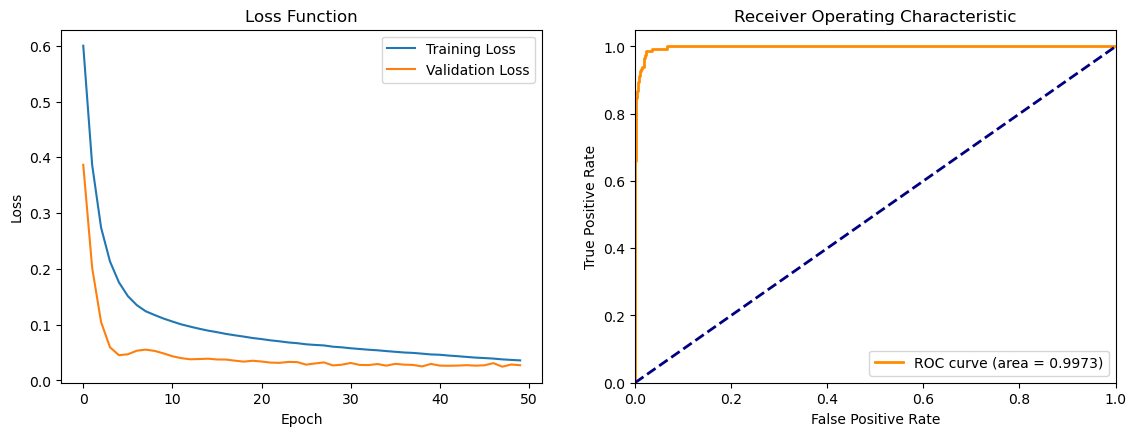

Test on positive and negative labels (150/2997):
Accuracy: 0.9886, Precision: 0.8904, Recall: 0.8667, F1 Score: 0.8784

Test on positive labels only (150):
Accuracy: 0.8667, Precision: 1.0, Recall: 0.8667, F1 Score: 0.9286



In [42]:
# Plot loss and roc curve
plot_loss_and_roc(train_results, model, X_test, y_test, batch_size=512)

# Positive and negative labels
eval_metrics(model, X_test, y_test)

# Only positive labels
eval_metrics(model, X_test, y_test, only_positives=True)

### Prediction

In [43]:
PREDICT_WITH_IMPUTE = False

if PREDICT_WITH_IMPUTE is True:
  df_predict = df_impute.copy()
else:
  df_predict = df_scaled.copy()

y_pred = predict_values(df_predict, df_predict.columns.tolist(), model, batch_size=4096, impute=False)
y_pred = y_pred.reshape(base_raster_array.shape)
y_pred = np.where(np.isnan(base_raster_array), np.nan, y_pred)

out_path = check_path(model_folder / "prediction") 
out_file = "prediction" + ".tif"
out_file_path = out_path / out_file
save_raster(out_file_path, array=y_pred, dtype="float32", metadata=base_raster.meta)   


35300/35300 [==============================] - 89s 2ms/step


In [44]:
# Clip to regional extent and shape
unified_raster, unified_meta = unify_raster_grids(PATH_BASE_RASTER_REG, [out_file_path], same_extent=True, same_shape=True)[0]
save_raster(out_path / str(out_file[:-4] + "_clip.tif"), array=unified_raster, dtype="float32", metadata=unified_meta)

# delete prediction file  
os.remove(out_file_path)

# Evaluate models

In [45]:
MODEL_NAME = "CPL_C2S_E50_BS32"
TIMESTAMP = "20240504-163925"

model_folder = MODEL_BASE_PATH / str(MODEL_NAME + "_" + TIMESTAMP)
# model = load_ml_model(MODEL_NAME, model_folder)

In [46]:
model.summary()

Model: "CPL_C2S_E50_BS512"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_layer (InputLayer)    [(None, 28)]              0         
                                                                 
 Hidden_layer_1 (Dense)      (None, 128)               3712      
                                                                 
 Hidden_layer_2 (Dense)      (None, 64)                8256      
                                                                 
 Hidden_layer_3 (Dense)      (None, 32)                2080      
                                                                 
 Output_layer (Dense)        (None, 1)                 33        
                                                                 
Total params: 14081 (55.00 KB)
Trainable params: 14081 (55.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [47]:
# Only positive labels
eval_metrics(model, X_test, y_test, only_positives=True)

Test on positive labels only (150):
Accuracy: 0.8667, Precision: 1.0, Recall: 0.8667, F1 Score: 0.9286



0.9972528083639194

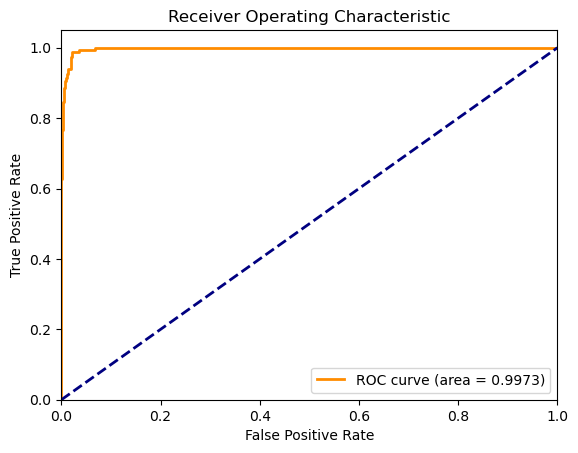

In [48]:
eval_roc_auc(model, X_test, y_test, plot=True)